# CIS6005 Computational Intelligence
## Notebook 08 — Model Evaluation
**Student Health Risk Prediction | Kaggle PS S6E7**

---
### Why Dedicated Evaluation?
In Phase 7 we trained the models. In this phase we **deeply analyse** their performance using multiple metrics:

| Metric | What It Measures | When to Use |
|--------|-----------------|-------------|
| **Accuracy** | Overall correct predictions | Balanced classes |
| **Precision** | Of all predicted positives, how many are correct | When false positives are costly |
| **Recall** | Of all actual positives, how many were found | When false negatives are costly |
| **F1-Score** | Harmonic mean of Precision and Recall | Imbalanced classes |
| **Cross-Validation** | Average performance across K folds | Most reliable single metric |

In [1]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing   import label_binarize

PROJECT_ROOT = Path.cwd().parent
PROC_DATA    = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR   = PROJECT_ROOT / 'models'

# Load data
X_train = np.load(PROC_DATA / 'X_train.npy')
X_val   = np.load(PROC_DATA / 'X_val.npy')
y_train = np.load(PROC_DATA / 'y_train.npy')
y_val   = np.load(PROC_DATA / 'y_val.npy')

label_encoder = joblib.load(MODELS_DIR / 'label_encoder.joblib')
CLASS_NAMES   = list(label_encoder.classes_)

# Load all models
model_files = {
    'Logistic Regression'  : 'model_logistic_regression.joblib',
    'K-Nearest Neighbours' : 'model_knn.joblib',
    'Decision Tree'        : 'model_decision_tree.joblib',
    'Random Forest'        : 'model_random_forest.joblib',
    'Gradient Boosting'    : 'model_gradient_boosting.joblib'
}

models = {}
for name, fname in model_files.items():
    path = MODELS_DIR / fname
    if path.exists():
        models[name] = joblib.load(path)
        print(f'  ✅ Loaded: {name}')
    else:
        print(f'  ❌ Missing: {fname} — Run Notebook 07 first')

# Full dataset for cross-validation
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

  ✅ Loaded: Logistic Regression
  ✅ Loaded: K-Nearest Neighbours
  ✅ Loaded: Decision Tree


  ✅ Loaded: Random Forest
  ✅ Loaded: Gradient Boosting


## 1. Comprehensive Metrics Table

In [2]:
# ============================================================
# SECTION 1: Comprehensive Metrics Table
# ============================================================

eval_results = []

for name, model in models.items():
    y_pred = model.predict(X_val)
    
    eval_results.append({
        'Model'         : name,
        'Accuracy'      : round(accuracy_score(y_val, y_pred), 4),
        'Precision'     : round(precision_score(y_val, y_pred, average='weighted', zero_division=0), 4),
        'Recall'        : round(recall_score(y_val, y_pred, average='weighted'), 4),
        'F1 (Weighted)' : round(f1_score(y_val, y_pred, average='weighted'), 4),
        'F1 (Macro)'    : round(f1_score(y_val, y_pred, average='macro'), 4)
    })

eval_df = pd.DataFrame(eval_results).sort_values('F1 (Weighted)', ascending=False)
eval_df = eval_df.reset_index(drop=True)

print('=' * 75)
print('  COMPREHENSIVE MODEL EVALUATION TABLE')
print('=' * 75)
print(eval_df.to_string(index=False))
print('=' * 75)

eval_df.to_csv(PROC_DATA / 'evaluation_metrics.csv', index=False)

  COMPREHENSIVE MODEL EVALUATION TABLE
               Model  Accuracy  Precision  Recall  F1 (Weighted)  F1 (Macro)
   Gradient Boosting    0.9655     0.9654  0.9655         0.9640      0.9035
K-Nearest Neighbours    0.9300     0.9270  0.9300         0.9242      0.7875
       Random Forest    0.9022     0.9297  0.9022         0.9101      0.7926
       Decision Tree    0.8580     0.9198  0.8580         0.8746      0.7334
 Logistic Regression    0.7986     0.8984  0.7986         0.8261      0.6574


## 2. Stratified K-Fold Cross Validation

**Why:** A single train/val split can be lucky or unlucky. Cross-validation (CV) splits the data K times and averages the results — giving a **more robust and trustworthy** performance estimate.

We use K=5 (5-Fold Stratified CV) — the industry standard.

In [3]:
# ============================================================
# SECTION 2: 5-Fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
print('Running 5-Fold Cross-Validation...')
print('=' * 60)
print(f'  {"Model":<25} {"CV Mean":>10} {"CV Std":>10} {"CV Min":>10} {"CV Max":>10}')
print('-' * 60)

# Downsample X_full/y_full to 50,000 samples for general cross-validation
np.random.seed(42)
idx_cv = np.random.choice(len(X_full), 50000, replace=False)
X_cv_subset = X_full[idx_cv]
y_cv_subset = y_full[idx_cv]

for name, model in models.items():
    # Avoid nested parallelism by setting estimator n_jobs to None
    if hasattr(model, 'n_jobs'):
        model.n_jobs = None
        
    if name == 'K-Nearest Neighbours':
        # KNN is extremely slow to cross-validate, downsample further to 20k
        np.random.seed(42)
        idx = np.random.choice(len(X_full), 20000, replace=False)
        scores = cross_val_score(
            model, X_full[idx], y_full[idx],
            cv=cv,
            scoring='f1_weighted',
            n_jobs=-1
        )
    else: 
        # Run CV on 50k samples
        scores = cross_val_score(
            model, X_cv_subset, y_cv_subset,
            cv=cv,
            scoring='f1_weighted',
            n_jobs=-1
        )
    
    cv_results.append({
        'Model'   : name,
        'CV Mean' : round(scores.mean(), 4),
        'CV Std'  : round(scores.std(), 4),
        'CV Min'  : round(scores.min(), 4),
        'CV Max'  : round(scores.max(), 4),
        'scores'  : scores
    })
    print(f'  {name:<25} {scores.mean():>10.4f} {scores.std():>10.4f} {scores.min():>10.4f} {scores.max():>10.4f}')

print('=' * 60)
print('\n📊 INTERPRETATION:')
print('   - Higher mean = better average performance')
print('   - Lower std = more consistent (less variance)')
print('   - The best model has HIGH mean AND LOW std')

Running 5-Fold Cross-Validation...
  Model                        CV Mean     CV Std     CV Min     CV Max
------------------------------------------------------------


  Logistic Regression           0.8237     0.0036     0.8198     0.8288


  K-Nearest Neighbours          0.9201     0.0049     0.9121     0.9264


  Decision Tree                 0.8761     0.0090     0.8603     0.8867


  Random Forest                 0.9519     0.0024     0.9478     0.9545


  Gradient Boosting             0.9612     0.0015     0.9597     0.9634

📊 INTERPRETATION:
   - Higher mean = better average performance
   - Lower std = more consistent (less variance)
   - The best model has HIGH mean AND LOW std


## 3. Cross-Validation Visualisation

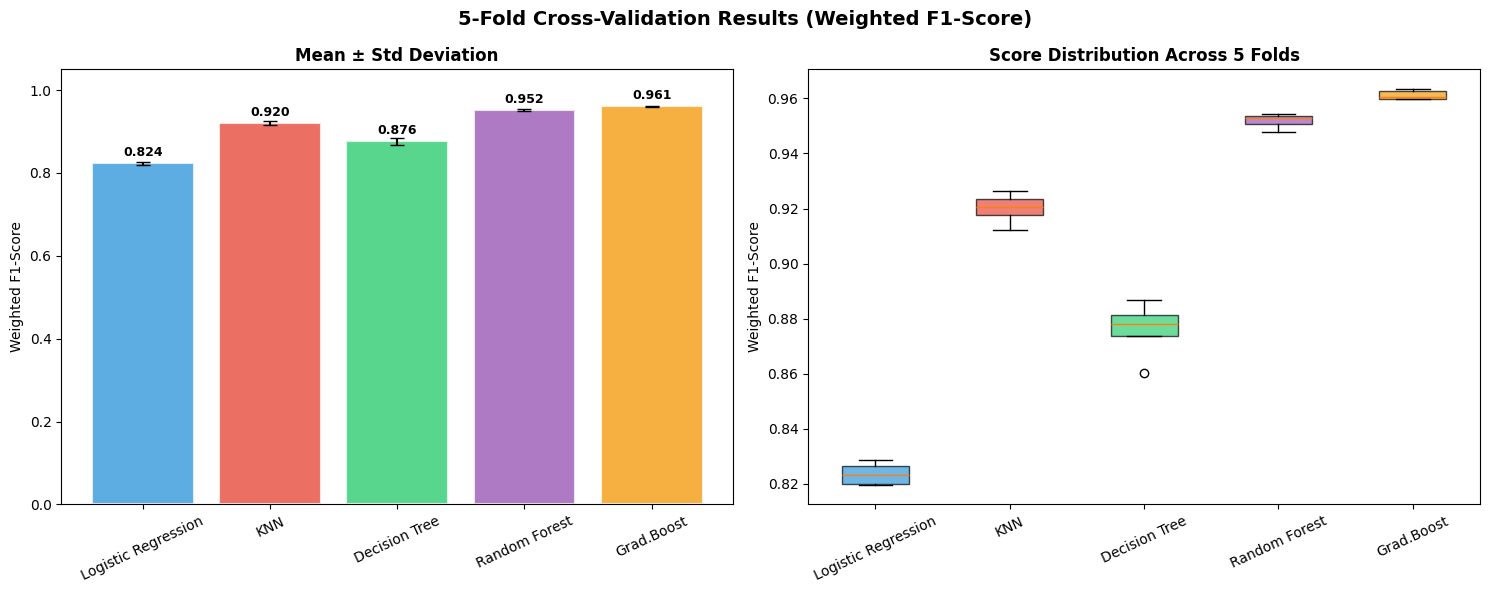

In [4]:
# ============================================================
# SECTION 3: CV Score Distribution Visualisation
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('5-Fold Cross-Validation Results (Weighted F1-Score)', fontsize=14, fontweight='bold')

# --- Bar chart with error bars ---
model_names_short = [r['Model'].replace('K-Nearest Neighbours', 'KNN').replace('Gradient Boosting', 'Grad.Boost') for r in cv_results]
means = [r['CV Mean'] for r in cv_results]
stds  = [r['CV Std']  for r in cv_results]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
bars = axes[0].bar(model_names_short, means, yerr=stds, capsize=5,
                   color=colors[:len(models)], alpha=0.8, edgecolor='white', linewidth=1.5)

axes[0].set_title('Mean ± Std Deviation', fontweight='bold')
axes[0].set_ylabel('Weighted F1-Score')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=25)

for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{mean:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# --- Box plot of fold scores ---
all_scores = [r['scores'] for r in cv_results]
bp = axes[1].boxplot(all_scores, labels=model_names_short, patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(models)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Score Distribution Across 5 Folds', fontweight='bold')
axes[1].set_ylabel('Weighted F1-Score')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(PROC_DATA / 'eval_01_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Importance (Random Forest)

**Why:** Feature importance tells us WHICH features the Random Forest found most useful. This is powerful for:
- Understanding the problem domain
- Reporting to stakeholders
- Potentially removing useless features (if time permits)

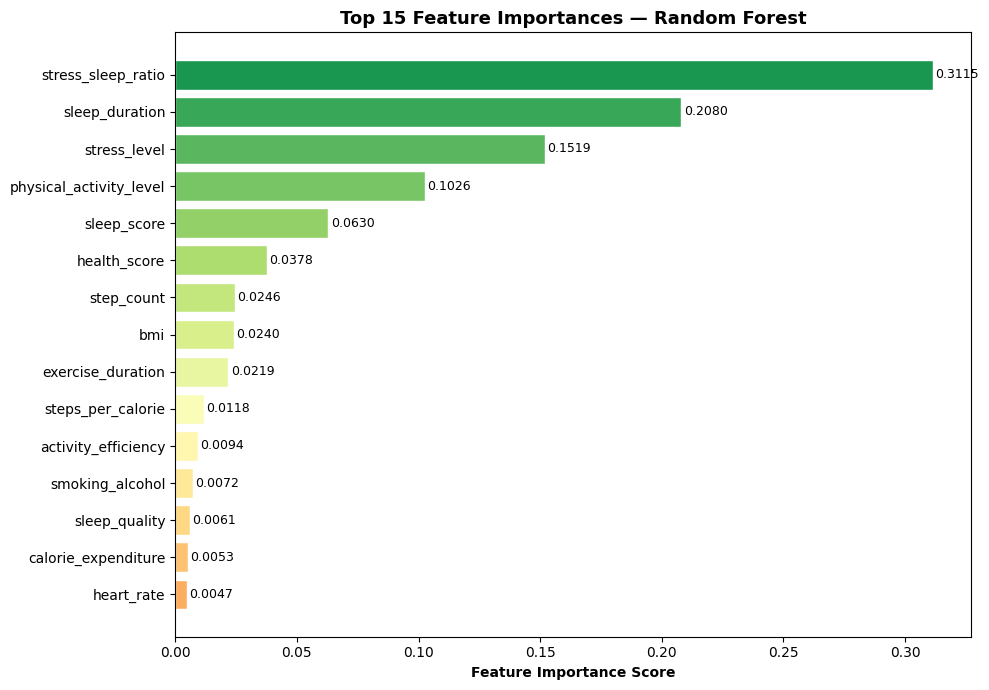


📊 Top 5 Most Important Features:
   stress_sleep_ratio            : 0.3115
   sleep_duration                : 0.2080
   stress_level                  : 0.1519
   physical_activity_level       : 0.1026
   sleep_score                   : 0.0630


In [5]:
# ============================================================
# SECTION 4: Feature Importance (Random Forest)
# ============================================================

feature_names = joblib.load(MODELS_DIR / 'feature_names.joblib')

if 'Random Forest' in models:
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    
    fi_df = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Plot top 15
    top_n = min(15, len(fi_df))
    fig, ax = plt.subplots(figsize=(10, 7))
    
    colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))[::-1]
    bars = ax.barh(
        fi_df['Feature'].head(top_n),
        fi_df['Importance'].head(top_n),
        color=colors_bar,
        edgecolor='white'
    )
    
    ax.set_xlabel('Feature Importance Score', fontweight='bold')
    ax.set_title(f'Top {top_n} Feature Importances — Random Forest', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    
    for bar, val in zip(bars, fi_df['Importance'].head(top_n)):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(PROC_DATA / 'eval_02_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('\n📊 Top 5 Most Important Features:')
    for _, row in fi_df.head(5).iterrows():
        print(f'   {row["Feature"]:<30}: {row["Importance"]:.4f}')

## 5. Identify the Best Model

In [6]:
# ============================================================
# SECTION 5: Best Model Selection
# ============================================================

# Sort by CV Mean score
cv_df = pd.DataFrame([{
    'Model'  : r['Model'],
    'CV Mean': r['CV Mean'],
    'CV Std' : r['CV Std']
} for r in cv_results]).sort_values('CV Mean', ascending=False)

best_model_name = cv_df.iloc[0]['Model']
best_cv_score   = cv_df.iloc[0]['CV Mean']

print('=' * 60)
print('  BEST MODEL SELECTION')
print('=' * 60)
print(f'  🏆 Best Model   : {best_model_name}')
print(f'  🎯 CV F1-Score  : {best_cv_score:.4f}')
print('=' * 60)
print(f'  → This model will be tuned in Phase 9')
print(f'  → Final model will be saved in Phase 12')
print('=' * 60)

# Save best model name for reference
joblib.dump(best_model_name, MODELS_DIR / 'best_model_name.joblib')
print('  ✅ Best model name saved for Phase 9')

  BEST MODEL SELECTION
  🏆 Best Model   : Gradient Boosting
  🎯 CV F1-Score  : 0.9612
  → This model will be tuned in Phase 9
  → Final model will be saved in Phase 12
  ✅ Best model name saved for Phase 9
